In [7]:
# -------------------------------------
# Library configuration
# -------------------------------------

# EDA methodology adapted from
# https://www.analyticsvidhya.com/blog/2022/07/step-by-step-exploratory-data-analysis-eda-using-python/

# Standard libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#to ignore warnings
import warnings
warnings.filterwarnings('ignore')

ImportError: Unable to import required dependencies:
numpy: cannot import name 'matvec' from 'numpy._core' (E:\py3-10\lib\site-packages\numpy\_core\__init__.py)

In [8]:
# Lucky number
random_state = 8

In [5]:
# Loading dataset
dataset = pd.read_csv('data/3-processed/data.csv')

dataset.head()

NameError: name 'pd' is not defined

In [6]:
dataset.tail()

NameError: name 'dataset' is not defined

In [ ]:
dataset.info()

In [ ]:
dataset.nunique()

In [ ]:
dataset.isnull().sum()

In [ ]:
# Check for duplicates on each row.
dataset.duplicated().value_counts()

In [ ]:
# Code snippet to help us see the percentage of missing values per column
(dataset.isnull().sum()/(len(dataset)))*100

In [ ]:
columns  = dataset.columns
print('Attributes',columns)

In [ ]:
for column in columns:
    print(column)

## Data Preprocessing

Preprocessing
Performs the following:

• Renames numerical codes into strings to make the values more readable.
• One-hot encodes categorical features.
• Drops selected features.
• Drops entries with unknown/blank personal or household income.
• Standardizes numerical features (makes mean=0 and standard deviation=1).
• Scales all features to the range [0, 1].

The Variables subsection indicates which features are categorical and numerical, and
which features are related to demographics, mental health, COVID, and coping be-
havior.
Running the whole Preprocessing section generates all preprocessing versions.

In [ ]:
# Sorting dataset based on SAMPLEID
dataset_sorted = dataset.sort_values(by=['SAMPLEID'])

In [ ]:
initial_rows = len(dataset_sorted)

# Drop all NaN rows, then ensure '5_PINCOME' and '5_HINCOME' are not missing
dataset_cleaned = dataset_sorted.dropna().dropna(subset=['5_PINCOME', '5_HINCOME'])

final_rows = len(dataset_cleaned)
print(f"Number of rows dropped: {initial_rows - final_rows}")


In [ ]:
# Gathering columns
column_names = dataset_cleaned.columns.tolist()

In [ ]:
# Displaying column names
column_names

In [ ]:
# Setting attributes
# Dropping Prefecture, Student, and PTG subscales
# as per Nunez 2022

# removed targets as well from attributes

# Setting attributes
attributes = dataset_cleaned[['5_SEX', '5_AGE', '5_MARRIED',
       '5_CHILD', '5_HINCOME', '5_PINCOME', '5_JOB',
       '5_Number_fam', '5_SchoolGrade', '5_YearsEnrolled', '5_VacNum',
       '5_UkraineMoviePicture', '5_UkraineReadListen', '5_Med_self',
       '5_Medself_covid', '5_Med_fam', '5_Medfam_covid', '5_Current_physical',
       '5_Past_physical', '5_Current_mental', '5_Past_mental',
       '5_Current_covid19', '5_Past_covid19', '5_K6_total', '5_PHQ9_total',
       '5_GAD7_total', '5_SSS8_total', '5_PTGI-X(Q7_39_44)', '5_MAIA_1',
       '5_MAIA_2', '5_MAIA_3', '5_MAIA_4', '5_MAIA_5', '5_MAIA_6', '5_MAIA_7',
       '5_MAIA_8', '5_SHS_total', '5_UCLA_total', '5_LSNS6_total', '5_AUDIT',
       '5_Exercise', '5_HealthyDiet', '5_FavoriteActivity',
       '5_Interaction_offline', '5_Interaction_online', '5_PB_Continuous',
       '5_PB_Altruistic', '5_PB_Avoidant', '5_Trust_gov', '5_Trust_SM',
       '5_Vaccination_will', '5_PB_understanding', '5_Optimism',
       '5_HealthySleep', '5_DeteriorationEconomy', '5_DeteriorationInteract',
       '5_Frustration', '5_CovidAnxiety', '5_CovidSleepless',
       '5_DifficultyLiving', '5_DifficultyWork',
       '5_Interest_Ukraine', '5_Support_Ukraine', '5_Support_Russia',
       '5_Age_group', '5_HINCOME_group', '5_JOB_group', '5_Med_group',
       '5_Med_covid_group', '5_Physical_group', '5_Mental_group',
       '5_Covid_group', '5_K6_group3', '5_K6_group2', '5_PHQ9_%', '5_GAD_%',
       '5_PHQ9_item9', '5_PHQ9_SI', '5_LSNS_group', '5_AUDIT_group']]

num_attributes = len(attributes.columns.tolist())

In [ ]:
num_attributes

In [ ]:
attributes.head(10)

In [ ]:
# Setting targets
targets = dataset_cleaned[
['6_K6_total',
 '6_PHQ9_total',
 '6_GAD7_total',
 '6_SSS8_total',
 '6_PTGI-X(Q7_22_27)',
 '6_SHS_total',
 '6_UCLA_total',
 '6_LSNS6_total',
 '6_AUDIT']]

num_targets = len(targets.columns.tolist())

In [2]:
targets.head(10)

NameError: name 'targets' is not defined

## PCA for dimensionality reduction

https://www.jcchouinard.com/pca-feature-importance/?utm_source=chatgpt.com

https://www.geeksforgeeks.org/feature-importance-in-pca-analyzing-loadings-and-biplots/

https://www.geeksforgeeks.org/feature-importance-in-pca-analyzing-loadings-and-biplots/?utm_source=chatgpt.com

In [21]:
from sklearn.preprocessing import StandardScaler  # to standardize the features
from sklearn.decomposition import PCA  # to apply PCA

# Standardize the features
scaler = StandardScaler()
scaled_data = scaler.fit_transform(attributes)  # Convert to NumPy array
scaled_data = pd.DataFrame(scaled_data, columns=attributes.columns)  # Restore column names

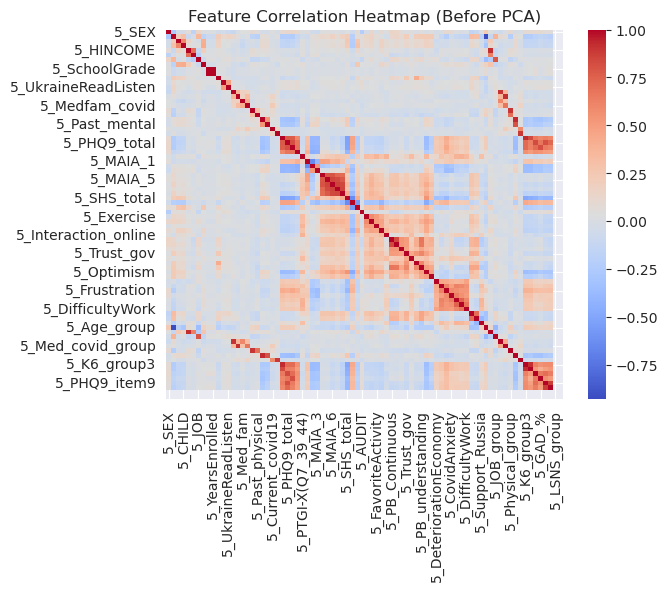

In [22]:
# Heatmap of feature correlation before PCA
sns.heatmap(scaled_data.corr(), cmap="coolwarm", annot=False)
plt.title("Feature Correlation Heatmap (Before PCA)")
plt.show()

In [23]:
# Fit PCA without specifying n_components
pca = PCA()
pca.fit(scaled_data)

PCA()

In [24]:
# Compute cumulative explained variance
explained_variance = np.cumsum(pca.explained_variance_ratio_)

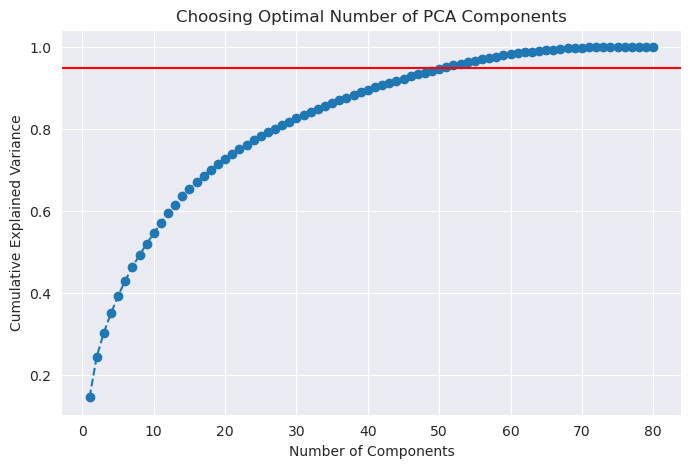

In [25]:
# Plot cumulative explained variance to find the "elbow point"
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o', linestyle='--')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Choosing Optimal Number of PCA Components')
plt.axhline(y=0.95, color='r', linestyle='-')  # 95% threshold
plt.show()

In [26]:
# Determine optimal number of components (first index where variance exceeds 95%)
optimal_n = np.argmax(explained_variance >= 0.95) + 1
print(f'Optimal number of components: {optimal_n}')

Optimal number of components: 51


In [27]:
# Apply PCA with the optimal number of components
pca_optimal = PCA(n_components=optimal_n)
data_pca = pca_optimal.fit_transform(scaled_data)

In [28]:
# Get the feature contributions to each Principal Component
pca_feature_contributions = pd.DataFrame(
    pca_optimal.components_,
    columns=attributes.columns,  # Original feature names
    index=[f'PC{i+1}' for i in range(optimal_n)]  # Keep PC labels for analysis
)

In [29]:
# Identify the most important features (attributes)
# Find the top contributing feature for each Principal Component
top_features_per_pc = pca_feature_contributions.abs().idxmax(axis=1)

In [30]:
# Get unique features that are most influential across all principal components
optimal_features = top_features_per_pc.unique()
print("\nOptimal Features Selected from Original Dataset:")
print(optimal_features)


Optimal Features Selected from Original Dataset:
['5_PHQ9_total' '5_MAIA_5' '5_DifficultyLiving' '5_Med_covid_group'
 '5_HINCOME_group' '5_Mental_group' '5_YearsEnrolled' '5_PINCOME'
 '5_Physical_group' '5_CHILD' '5_JOB' '5_UkraineMoviePicture'
 '5_Med_group' '5_VacNum' '5_Med_fam' '5_K6_group2' '5_AUDIT'
 '5_Current_covid19' '5_HealthySleep' '5_DeteriorationEconomy'
 '5_Past_physical' '5_Interaction_online' '5_GAD_%' '5_CovidAnxiety'
 '5_Interaction_offline' '5_DeteriorationInteract' '5_PTGI-X(Q7_39_44)'
 '5_MAIA_3' '5_UkraineReadListen' '5_MARRIED' '5_Past_mental'
 '5_FavoriteActivity' '5_Number_fam' '5_DifficultyWork' '5_Trust_gov'
 '5_HealthyDiet' '5_Frustration' '5_PHQ9_%']


In [31]:
# Filter the original dataset to keep only the most important attributes
dataset_optimal = attributes[list(optimal_features)]

dataset_optimal.head()

,5_PHQ9_total,5_MAIA_5,5_DifficultyLiving,5_Med_covid_group,5_HINCOME_group,5_Mental_group,5_YearsEnrolled,5_PINCOME,5_Physical_group,5_CHILD,...,5_UkraineReadListen,5_MARRIED,5_Past_mental,5_FavoriteActivity,5_Number_fam,5_DifficultyWork,5_Trust_gov,5_HealthyDiet,5_Frustration,5_PHQ9_%
4,5.0,2.0,6.0,4.0,4.0,4.0,0.0,3.0,4.0,2.0,...,0.5,2.0,2.0,4.0,2.0,1.0,1.0,5.0,1.0,0.0
8,0.0,0.8,1.0,4.0,5.0,4.0,0.0,1.0,4.0,2.0,...,0.1,2.0,2.0,6.0,3.0,1.0,7.0,7.0,1.0,0.0
11,0.0,2.0,1.0,4.0,3.0,4.0,0.0,3.0,4.0,1.0,...,0.1,1.0,2.0,5.0,0.0,1.0,4.0,3.0,2.0,0.0
15,0.0,1.8,2.0,4.0,5.0,4.0,0.0,3.0,4.0,2.0,...,0.5,2.0,2.0,4.0,4.0,2.0,4.0,5.0,2.0,0.0
19,0.0,2.0,4.0,4.0,6.0,4.0,0.0,10.0,4.0,2.0,...,0.0,2.0,2.0,5.0,1.0,4.0,2.0,2.0,4.0,0.0


# UCLA DATASET

In [32]:
## UCLA Dataset
# Declaring function for UCLA Loneliness Scale (UCLA LS)
def condition(x):
    if 0 <= x <= 19:
        return 'Minimal loneliness'
    elif 20 <= x <= 34:
        return 'Low'
    elif 35 <= x <= 49:
        return 'Moderate'
    elif 50 <= x <= 64:
        return 'Moderately high'
    elif 65 <= x <= 80:
        return 'High'

In [33]:
attributes = dataset_optimal

target_name = '6_UCLA_total'

target_column = targets[[target_name]].rename(columns={target_name: 'TARGET'})
attributes.columns = attributes.columns.str.lower().str.replace('^5_', '', regex=True)
dataset = pd.concat([attributes, target_column], axis=1)

dataset.head(10)

,phq9_total,maia_5,difficultyliving,med_covid_group,hincome_group,mental_group,yearsenrolled,pincome,physical_group,child,...,married,past_mental,favoriteactivity,number_fam,difficultywork,trust_gov,healthydiet,frustration,phq9_%,TARGET
4,5.0,2.0,6.0,4.0,4.0,4.0,0.0,3.0,4.0,2.0,...,2.0,2.0,4.0,2.0,1.0,1.0,5.0,1.0,0.0,24.0
8,0.0,0.8,1.0,4.0,5.0,4.0,0.0,1.0,4.0,2.0,...,2.0,2.0,6.0,3.0,1.0,7.0,7.0,1.0,0.0,11.0
11,0.0,2.0,1.0,4.0,3.0,4.0,0.0,3.0,4.0,1.0,...,1.0,2.0,5.0,0.0,1.0,4.0,3.0,2.0,0.0,32.0
15,0.0,1.8,2.0,4.0,5.0,4.0,0.0,3.0,4.0,2.0,...,2.0,2.0,4.0,4.0,2.0,4.0,5.0,2.0,0.0,21.0
19,0.0,2.0,4.0,4.0,6.0,4.0,0.0,10.0,4.0,2.0,...,2.0,2.0,5.0,1.0,4.0,2.0,2.0,4.0,0.0,22.0
21,4.0,0.0,4.0,4.0,3.0,4.0,0.0,3.0,2.0,2.0,...,1.0,2.0,1.0,0.0,4.0,7.0,1.0,4.0,0.0,24.0
22,0.0,2.2,2.0,4.0,3.0,4.0,0.0,2.0,4.0,2.0,...,2.0,2.0,6.0,1.0,2.0,6.0,6.0,2.0,0.0,23.0
24,9.0,2.6,1.0,4.0,6.0,4.0,0.0,3.0,4.0,1.0,...,1.0,2.0,4.0,1.0,5.0,4.0,4.0,4.0,0.0,28.0
27,4.0,1.0,2.0,4.0,4.0,4.0,0.0,3.0,4.0,1.0,...,1.0,2.0,4.0,2.0,1.0,5.0,4.0,5.0,0.0,29.0
31,2.0,3.4,1.0,4.0,4.0,4.0,0.0,4.0,4.0,1.0,...,1.0,2.0,4.0,0.0,2.0,5.0,5.0,3.0,0.0,28.0


In [34]:
# Count the frequency of each label
dataset['TARGET'] = dataset['TARGET'].apply(condition)

label_counts = dataset['TARGET'].value_counts()

print(label_counts)

TARGET
Low                   1907
Minimal loneliness     633
Moderate               119
Name: count, dtype: int64


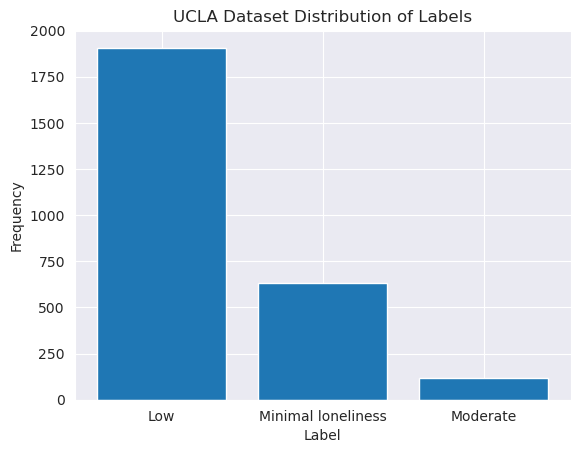

In [35]:
# Plot the bar chart
plt.bar(label_counts.index, label_counts.values)

# Add labels and title
plt.xlabel('Label')
plt.ylabel('Frequency')
plt.title('UCLA Dataset Distribution of Labels')

# Show the plot
plt.show()

# Splitting datasets

In [36]:
# -------------------------------------
# Library configuration
# -------------------------------------

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score

from sklearn.ensemble import RandomForestClassifier

In [37]:
# Extract the target and features
y = dataset['TARGET']
X = dataset.drop(columns=['TARGET'])

# Encode the labels
encoder = LabelEncoder()
encoded_label = encoder.fit_transform(y)

# Reflect encoder changes in y
y_encoded = encoder.transform(y)

#Get the training and test set from the K6 dataset
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state= 30)

# Calculate the count of each unique label
unique_labels, label_counts = np.unique(y_test, return_counts=True)

In [38]:
labels = []

print("Test data distribution")
for label, count in zip(unique_labels, label_counts):
    label_name = encoder.inverse_transform([label])[0]
    labels.append(label_name)
    print(f"Label: {label_name}, Count: {count}")

Test data distribution
Label: Low, Count: 572
Label: Minimal loneliness, Count: 181
Label: Moderate, Count: 45


In [39]:
print(labels)

['Low', 'Minimal loneliness', 'Moderate']


# Model Training

In [40]:
# -------------------------------------
# Library configuration
# -------------------------------------

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, \
    f1_score

from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

In [41]:
# Define a function to train and predict using a given model
def train_and_predict(model, X_train, y_train, X_test):
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    return predictions

# Define a function to evaluate the model's predictions
def evaluate_model(y_test, predictions):
    accuracy = accuracy_score(y_test, predictions) * 100
    precision = precision_score(y_test, predictions, average='macro') * 100
    recall = recall_score(y_test, predictions, average='macro') * 100
    f1 = f1_score(y_test, predictions, average='macro') * 100
    return accuracy, precision, recall, f1


# Define a function to print evaluation metrics
def print_evaluation_metrics(accuracy, precision, recall, f1):
    print(f"Accuracy: {accuracy:.10f}")
    print(f"Precision: {precision:.10f}")
    print(f"Recall: {recall:.10f}")
    print(f"F1-score: {f1:.10f}")

# List of models to test
models = [
    ("Random Forest", RandomForestClassifier(random_state=random_state)),
    ("K-Nearest Neighbors", KNeighborsClassifier()),
    ("Decision Tree", DecisionTreeClassifier(random_state=random_state)),
    ("Gaussian Naive Bayes", GaussianNB()),
    ("Support Vector Machine", SVC(random_state=random_state)),
    ("MLP Classifier", MLPClassifier(random_state=random_state))
]

In [42]:
for model_name, model in models:
    print(f"\n  Model: {model_name}")
    predictions = train_and_predict(model, X_train, y_train, X_test)
    accuracy, precision, recall, f1 = evaluate_model(y_test, predictions)
    print_evaluation_metrics(accuracy, precision, recall, f1)


  Model: Random Forest
Accuracy: 76.0651629073
Precision: 73.9899430222
Recall: 47.0408004110
F1-score: 49.8262072783

  Model: K-Nearest Neighbors
Accuracy: 72.1804511278
Precision: 61.7613380400
Recall: 46.2745746171
F1-score: 49.2713703059

  Model: Decision Tree
Accuracy: 66.5413533835
Precision: 47.0310801068
Recall: 46.9584640855
F1-score: 46.9814185579

  Model: Gaussian Naive Bayes
Accuracy: 27.5689223058
Precision: 43.4240362812
Recall: 60.2610608135
F1-score: 26.2405757286

  Model: Support Vector Machine
Accuracy: 75.1879699248
Precision: 47.0372912377
Recall: 42.5182552254
F1-score: 42.7896129729

  Model: MLP Classifier
Accuracy: 71.4285714286
Precision: 57.3317505091
Recall: 48.4758693322
F1-score: 51.1806257203


In [43]:
best_model = RandomForestClassifier(random_state=random_state)
best_model.fit(X_train, y_train)

RandomForestClassifier(random_state=8)

In [44]:
predictions = best_model.predict(X_test)

[[532  39   1]
 [110  71   0]
 [ 40   1   4]]


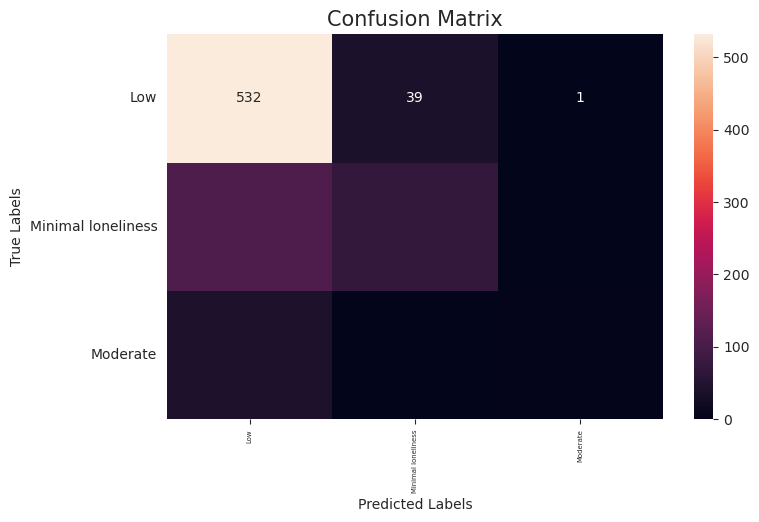

In [45]:
#Confusion matrix
cm = confusion_matrix(y_test, predictions)
print(cm)

#Plot the Confusion matrix graph
fig = plt.figure(figsize=(8, 5))
ax = plt.subplot()
sns.heatmap(cm, annot=True, ax=ax, fmt='g')
ax.set_xlabel('Predicted Labels', fontsize=10)
ax.xaxis.set_label_position('bottom')
plt.xticks(rotation=90)
ax.xaxis.set_ticklabels(labels, fontsize=5)
ax.xaxis.tick_bottom()

ax.set_ylabel('True Labels', fontsize=10)
ax.yaxis.set_ticklabels(labels, fontsize=10)
plt.yticks(rotation=0)

plt.title('Confusion Matrix', fontsize=15)

plt.show()

In [46]:
#Classification report
print(classification_report(y_test, predictions, target_names = labels))

                    precision    recall  f1-score   support

               Low       0.78      0.93      0.85       572
Minimal loneliness       0.64      0.39      0.49       181
          Moderate       0.80      0.09      0.16        45

          accuracy                           0.76       798
         macro avg       0.74      0.47      0.50       798
      weighted avg       0.75      0.76      0.73       798



In [47]:
# Evaluate the model using accuracy, precision, recall, and F1-score
accuracy = accuracy_score(y_test, predictions)
precision = precision_score(y_test, predictions, average='macro')
recall = recall_score(y_test, predictions, average='macro')
f1 = f1_score(y_test, predictions, average='macro')


# Print the evaluation metrics
print("Accuracy: %.f" %(accuracy*100))
print("Precision: %.f" %(precision*100))
print("Recall: %.f" %(recall*100))
print("F1-score: %.f" %(f1*100))

Accuracy: 76
Precision: 74
Recall: 47
F1-score: 50


## Hyperparameter Tuning
# this takes so long to run
# please skip for now

In [51]:
import pprint
import joblib as job
import time

from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
import sklearn.metrics as metrics

pp = pprint.PrettyPrinter(indent=1)

In [52]:
# Define hyperparameter space
n_estimators = [100, 250, 500, 1000]                       # Range of trees
max_features = ['sqrt', 'log2']                 # Feature selection
max_depth = [int(x) for x in np.linspace(10, 100, num=10)]
max_depth.append(None) # Depth
min_samples_split = [2, 5, 10, 15]                     # Control overfitting
min_samples_leaf = [1, 2, 4, 6]                       # Prevent overfitting
bootstrap = [True, False]                              # Sampling strategy
class_weight = ['balanced', None]               # Handling of imbalanced classes
cv = 10                                         # Cross-validation folds

# Create the random grid
random_grid = {
    'n_estimators': n_estimators,
    'max_features': max_features,
    'max_depth': max_depth,
    'min_samples_split': min_samples_split,
    'min_samples_leaf': min_samples_leaf,
    'bootstrap': bootstrap,
    'class_weight': class_weight
}

print('Hyperparameter search space:')
pp.pprint(random_grid)

# Set the hyperparameter tuner
start_time = time.time()
model = RandomForestClassifier(random_state=random_state, verbose=0)

# Randomized Search CV
print("\nStarting Randomized Search CV...")
tuner = RandomizedSearchCV(estimator=model,
                           param_distributions=random_grid,
                           n_iter=200,
                           cv=10,
                           scoring='r2',
                           random_state=random_state,
                           verbose=1,
                           return_train_score=True,
                           n_jobs=10)

# Fit the random search model
print("Fitting the Randomized Search model...")
tuner.fit(X_train, y_train)
print("Randomized Search CV completed.")

# Time taken for Randomized Search
end_time = time.time()
running_time = end_time - start_time
print('\nRandom Forest training time:', running_time, 's')

# Now, if you want to continue with Grid Search
print("\nStarting Grid Search CV...")
tuner_grid = GridSearchCV(estimator=model,
                          param_grid=random_grid,
                          cv=cv,
                          scoring='r2',
                          verbose=6,
                          return_train_score=True,
                          n_jobs=10)

# Fit the grid search model
print("Fitting the Grid Search model...")
tuner_grid.fit(X_train, y_train)
print("Grid Search CV completed.")

# Time taken for Grid Search
end_time_grid = time.time()
running_time_grid = end_time_grid - end_time
print('\nGrid Search training time:', running_time_grid, 's')

Hyperparameter search space:
{'bootstrap': [True, False],
 'class_weight': ['balanced', None],
 'max_depth': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, None],
 'max_features': ['sqrt', 'log2'],
 'min_samples_leaf': [1, 2, 4, 6],
 'min_samples_split': [2, 5, 10, 15],
 'n_estimators': [100, 250, 500, 1000]}

Starting Randomized Search CV...
Fitting the Randomized Search model...
Fitting 10 folds for each of 200 candidates, totalling 2000 fits


KeyboardInterrupt: 

In [ ]:
# Save the model
model_name = type(tuner).__name__
file_name = model_name + '_' + time.strftime("%Y%m%d-%H%M%S") + '.mod'
file_save = file_name

print('Saving', model_name, 'model as', file_name, '...')
job.dump(tuner, file_save)

In [ ]:
# Load the model
file_model = '-----'
file_load = file_model

saved_model = job.load(file_load)
tuner = saved_model

print('Best hyperparameters:')
pp.pprint(tuner.best_estimator_.get_params())

In [ ]:
# Check the tuned model
print('Best hyperparameters:')
print(tuner.best_estimator_)

## Cross-validation Results
# skip this too

In [ ]:
## Plot CV results
def plot_cv(tuner):
    results = tuner.cv_results_
    cv_params = tuner.param_distributions
    means_test = results['mean_test_score']
    stds_test = results['std_test_score']
    means_train = results['mean_train_score']
    stds_train = results['std_train_score']

    print(cv_params)
    fig, ax = plt.subplots(1, len(cv_params), sharex='none', sharey='all', figsize=(20,8), dpi=300)
    fig.suptitle('Hyperparameter Tuning')
    fig.text(0.04, 0.5, 'MEAN SCORE', va='center', rotation='vertical')

    scores = {}
    for i, (param, param_val) in enumerate(cv_params.items()):
        x, y1, e1, y2, e2 = [], [], [], [], []

        for v in param_val:
            mask_idx = results['param_'+param]==v
            v = str(v)

            m_train = np.mean(means_train[mask_idx])
            s_train = np.sqrt(np.mean(stds_train[mask_idx]**2))
            m_test = np.mean(means_test[mask_idx])
            s_test = np.sqrt(np.mean(stds_test[mask_idx]**2))

            scores[param+'='+v+'_means_train'] = m_train
            scores[param+'='+v+'_stds_train'] = s_train
            scores[param+'='+v+'_means_test'] = m_test
            scores[param+'='+v+'_stds_test'] = s_test
            print(param, "=", v, ":", m_test)

            x.append(v)
            y1.append(m_train)
            e1.append(s_train)
            y2.append(m_test)
            e2.append(s_test)

        ax[i].errorbar(x, y1, e1, linestyle='-', marker='^', label='Train')
        ax[i].errorbar(x, y2, e2, linestyle='--', marker='o', color='g', label='CV')
        ax[i].set_xlabel(param.upper())

    # pp.pprint(scores)

    plt.legend()
    plt.show()

sns.set_style('dark')
plot_cv(tuner)
print(tuner.cv_results_)
plot_cv(saved_model)

In [ ]:
## Evaluate model
def evaluate(model, X, y_actual):
    y_predicted = model.predict(X)
    mae = metrics.mean_absolute_error(y_actual, y_predicted)
    mse = metrics.mean_squared_error(y_actual, y_predicted)
    rmse = np.sqrt(mse)
    re = np.divide(np.abs(y_actual - y_predicted), y_actual) * 100
    mre = np.mean(re)
    r2 = model.score(X, y_actual)

    print('Model Performance')
    print('MAE: {:0.4f}'.format(mae))
    print('MSE: {:0.4f}'.format(mse))
    print('RMSE: {:0.4f}'.format(rmse))
    print('MRE: {:0.4f}%'.format(mre))
    print('R2: {:0.4f}'.format(r2))

    return r2

print('Base model')
base_model = RandomForestClassifier(random_state=random_state)
base_model.fit(X_train, y_train)
base_accuracy = evaluate(base_model, X_test, y_test)

print('\nTuned model')
tuned_model = tuner.best_estimator_
tuned_accuracy = evaluate(tuned_model, X_test, y_test)

print('\nSaved model')
saved_accuracy = evaluate(saved_model.best_estimator_, X_test, y_test)

print('\nImprovement: {:0.2f}'.format(tuned_accuracy - base_accuracy))

In [ ]:
predictions = tuned_model.predict(X_test)

In [ ]:
#Confusion matrix
cm = confusion_matrix(y_test, predictions)
print(cm)

#Plot the Confusion matrix graph
fig = plt.figure(figsize=(8, 5))
ax = plt.subplot()
sns.heatmap(cm, annot=True, ax=ax, fmt='g')
ax.set_xlabel('Predicted Labels', fontsize=10)
ax.xaxis.set_label_position('bottom')
plt.xticks(rotation=90)
ax.xaxis.set_ticklabels(labels, fontsize=5)
ax.xaxis.tick_bottom()

ax.set_ylabel('True Labels', fontsize=10)
ax.yaxis.set_ticklabels(labels, fontsize=10)
plt.yticks(rotation=0)

plt.title('Confusion Matrix', fontsize=15)

plt.show()

In [ ]:
#Classification report
print(classification_report(y_test, predictions, target_names = labels))

In [ ]:
# Evaluate the model using accuracy, precision, recall, and F1-score
accuracy = accuracy_score(y_test, predictions)
precision = precision_score(y_test, predictions, average='macro')
recall = recall_score(y_test, predictions, average='macro')
f1 = f1_score(y_test, predictions, average='macro')


# Print the evaluation metrics
print("Accuracy: %.f" %(accuracy*100))
print("Precision: %.f" %(precision*100))
print("Recall: %.f" %(recall*100))
print("F1-score: %.f" %(f1*100))

# Prediction Probabilities
# skipppppp

In [ ]:
y_predict_proba = model.predict_proba(X_test)
plt.figure(figsize=(10, 6))
sns.histplot(y_predict_proba.max(axis=1), bins=20, kde=True)
plt.xlabel("Maximum Predicted Probability")
plt.ylabel("Frequency")
plt.title("Prediction Confidence Distribution")
plt.show()

# Explainer

In [53]:
#!pip install explainerdashboard
#!pip install -U explainerdashboard

In [48]:
from explainerdashboard import ClassifierExplainer, ExplainerDashboard
explainer = ClassifierExplainer(best_model, X_test, y_test, labels=labels)

from explainerdashboard import ExplainerDashboard
db = ExplainerDashboard(explainer,
                        # importances tab
                        importances=True,
                        hide_globalcutoff=True,
                        hide_cutoff=True,

                        # model summary tab
                        model_summary=True,

                        # contributions tab
                        contributions=True,

                        # what if tab
                        whatif=True,

                        # shap dependence tab
                        shap_dependenc=True,

                        # tabs turned off
                        shap_interaction=False,
                        decision_trees=False)

Detected RandomForestClassifier model: Changing class type to RandomForestClassifierExplainer...
Note: model_output=='probability', so assuming that raw shap output of RandomForestClassifier is in probability space...
Generating self.shap_explainer = shap.TreeExplainer(model)
Building ExplainerDashboard..
Detected notebook environment, consider setting mode='external', mode='inline' or mode='jupyterlab' to keep the notebook interactive while the dashboard is running...
Generating layout...
Calculating shap values...
Calculating prediction probabilities...
Calculating metrics...
Calculating confusion matrices...
Calculating classification_dfs...
Calculating roc auc curves...
Calculating pr auc curves...
Calculating liftcurve_dfs...
Calculating dependencies...
Calculating permutation importances (if slow, try setting n_jobs parameter)...
Calculating predictions...
Calculating pred_percentiles...
Reminder: you can store the explainer (including calculated dependencies) with explainer.dump

In [49]:
db.run()

Starting ExplainerDashboard on http://10.13.9.107:8050


# Counterfactuals

https://github.com/andreArtelt/ceml

In [59]:
import dice_ml
from dice_ml.utils import helpers # helper functions
from sklearn.model_selection import train_test_split

dataset = helpers.load_adult_income_dataset()
target = dataset["income"] # outcome variable
train_dataset, test_dataset, _, _ = train_test_split(dataset,
                                                     target,
                                                     test_size=0.2,
                                                     random_state=0,
                                                     stratify=target)
# Dataset for training an ML model
d = dice_ml.Data(dataframe=train_dataset,
                 continuous_features=['age', 'hours_per_week'],
                 outcome_name='income')

# Pre-trained ML model
m = dice_ml.Model(model_path=dice_ml.utils.helpers.get_adult_income_modelpath(),
                  backend='TF2', func="ohe-min-max")
# DiCE explanation instance
exp = dice_ml.Dice(d,m)

ModuleNotFoundError: No module named 'dice_ml'